In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16, DenseNet121
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import random
import itertools
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, hamming_loss, f1_score
import pandas as pd
from tensorflow.keras.utils import Sequence

In [2]:
#### Configuration

In [3]:
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 50
DATA_PATH   = "Data_segrigation_Augmented"
NUM_CLASSES = 8

# Blending config
# BLEND_RATIO controls how many synthetic 2-disease images to generate
# relative to real single-disease images. 0.3 = 30% extra blended images.
BLEND_RATIO  = 0.3
BLEND_ALPHA  = 0.55   # weight of the primary disease image (0.5-0.65 works well)

# Inference threshold — lower = catches more diseases, higher = fewer false alarms
# 0.35 is a good starting point for agricultural disease detection
THRESHOLD = 0.35

os.makedirs("saved_model", exist_ok=True)
os.makedirs("training_history", exist_ok=True)

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

In [4]:
raw_class_names = sorted([
    d for d in os.listdir(DATA_PATH)
    if os.path.isdir(os.path.join(DATA_PATH, d))
])

CLASS_NAMES = raw_class_names
NUM_CLASSES = len(CLASS_NAMES)

class_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}

# Build dict: class_name → list of image paths
class_images = {}
for cls in CLASS_NAMES:
    cls_path = os.path.join(DATA_PATH, cls)
    imgs = [
        os.path.join(cls_path, f)
        for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    class_images[cls] = imgs

print(f"Found {NUM_CLASSES} classes:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  [{i}] {cls:30} — {len(class_images[cls])} images")

print(f"\n*** Copy this class order to your mobile app's CLASS_NAMES list ***")

Found 8 classes:
  [0] Bacteria Blight                — 408 images
  [1] Brown spot                     — 742 images
  [2] Caterpillar Damage             — 378 images
  [3] Dry                            — 250 images
  [4] Healthy                        — 1564 images
  [5] Kanamadiri haniya              — 452 images
  [6] Leaf spot                      — 1561 images
  [7] Red Spider mite Damage         — 399 images

*** Copy this class order to your mobile app's CLASS_NAMES list ***


In [5]:
####Build Single-Label + Synthetic Multi-Label Dataset

Loading single-label images...
  Loaded 5754 real single-label images

Generating synthetic 2-disease images...
  Generated 1722 synthetic 2-disease images
  Total dataset size: 7476 images
    — Single-label : 5754
    — Multi-label  : 1722


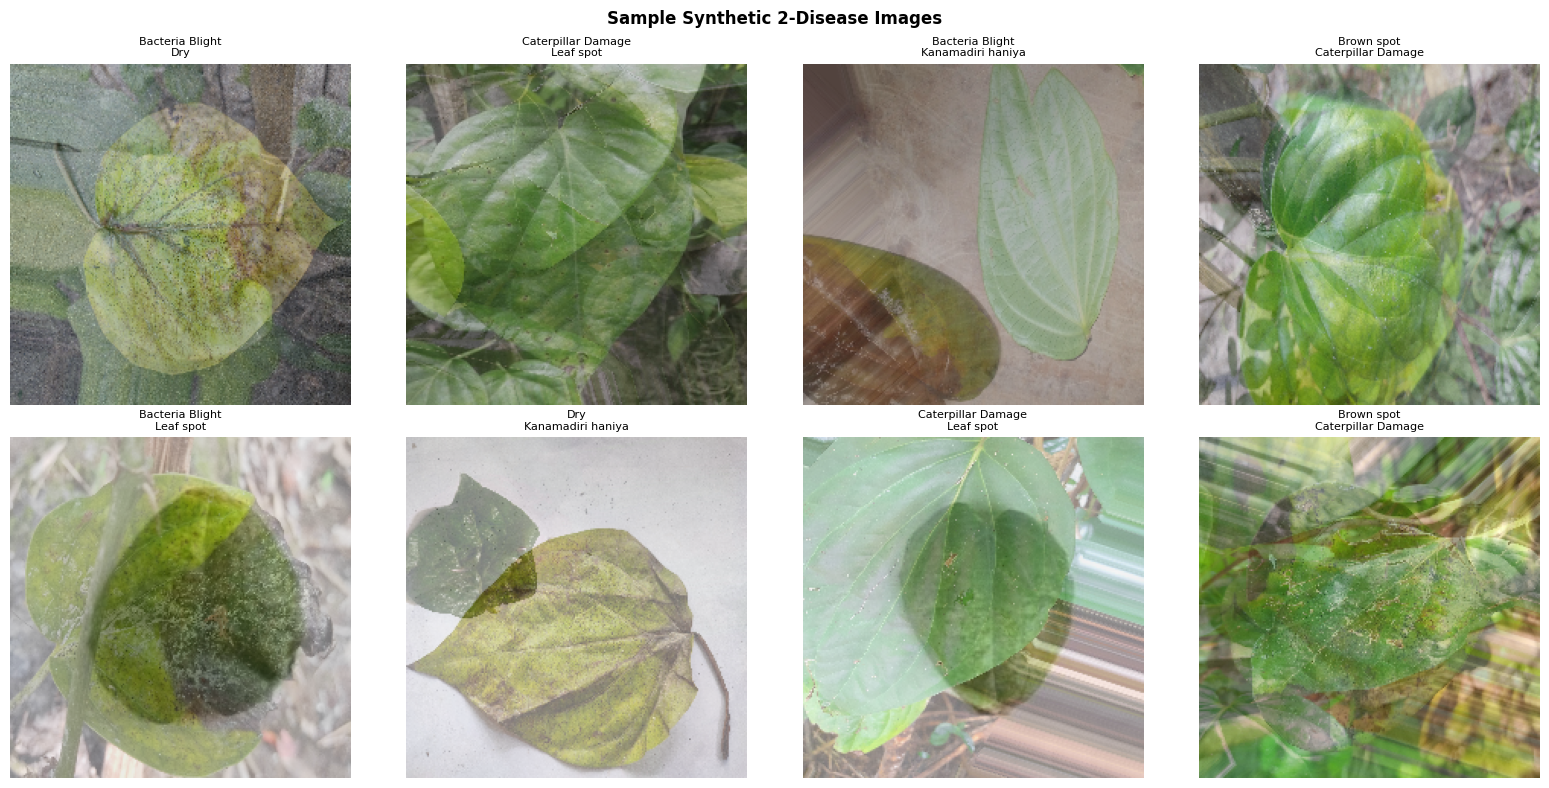

Saved: training_history/synthetic_samples.png


In [6]:
def load_and_preprocess(path):
    """Load image, resize, normalize to [0,1]."""
    img = load_img(path, target_size=IMG_SIZE)
    return img_to_array(img) / 255.0

def make_multihot(class_indices):
    """Create a multi-hot label vector for a list of class indices."""
    label = np.zeros(NUM_CLASSES, dtype=np.float32)
    for idx in class_indices:
        label[idx] = 1.0
    return label

def blend_images(path1, path2, alpha=BLEND_ALPHA):
    """
    Blend two disease images to simulate co-occurrence.
    alpha controls how much of image1 is preserved (0.5-0.65 recommended).
    The result looks like a leaf showing symptoms of both diseases.
    """
    img1 = load_and_preprocess(path1)
    img2 = load_and_preprocess(path2)
    blended = alpha * img1 + (1.0 - alpha) * img2
    return np.clip(blended, 0.0, 1.0)

# ── Collect all samples ───────────────────────────────────────────────────────

all_images  = []   # list of np arrays, shape (224,224,3)
all_labels  = []   # list of multi-hot vectors, shape (NUM_CLASSES,)

print("Loading single-label images...")
for cls, paths in class_images.items():
    idx = class_to_idx[cls]
    for path in paths:
        all_images.append(load_and_preprocess(path))
        all_labels.append(make_multihot([idx]))

n_real = len(all_images)
print(f"  Loaded {n_real} real single-label images")

# ── Generate synthetic 2-disease images ──────────────────────────────────────

print("\nGenerating synthetic 2-disease images...")

# Only blend DISEASE classes — skip 'Healthy' (index of Healthy class)
healthy_idx  = class_to_idx.get('Healthy', -1)
disease_classes = [cls for cls in CLASS_NAMES if cls != 'Healthy']

# Generate all pairs of disease classes
disease_pairs = list(itertools.combinations(disease_classes, 2))

# Calculate how many blended images to generate total
n_synthetic = int(n_real * BLEND_RATIO)
pairs_per_combo = max(1, n_synthetic // len(disease_pairs))

synthetic_count = 0
for cls1, cls2 in disease_pairs:
    paths1 = class_images[cls1]
    paths2 = class_images[cls2]
    idx1   = class_to_idx[cls1]
    idx2   = class_to_idx[cls2]

    for _ in range(pairs_per_combo):
        p1 = random.choice(paths1)
        p2 = random.choice(paths2)

        blended = blend_images(p1, p2)
        label   = make_multihot([idx1, idx2])

        all_images.append(blended)
        all_labels.append(label)
        synthetic_count += 1

all_images = np.array(all_images, dtype=np.float32)
all_labels = np.array(all_labels, dtype=np.float32)

print(f"  Generated {synthetic_count} synthetic 2-disease images")
print(f"  Total dataset size: {len(all_images)} images")
print(f"    — Single-label : {n_real}")
print(f"    — Multi-label  : {synthetic_count}")

# Visualise a few blended samples
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
multi_label_indices = [i for i, lbl in enumerate(all_labels) if lbl.sum() > 1]
sample_indices = random.sample(multi_label_indices, min(8, len(multi_label_indices)))

for ax, idx in zip(axes, sample_indices):
    ax.imshow(all_images[idx])
    diseases = [CLASS_NAMES[j] for j in range(NUM_CLASSES) if all_labels[idx][j] == 1]
    ax.set_title("\n".join(diseases), fontsize=8)
    ax.axis('off')

plt.suptitle("Sample Synthetic 2-Disease Images", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history/synthetic_samples.png', dpi=120)
plt.show()
print("Saved: training_history/synthetic_samples.png")

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    all_images, all_labels,
    test_size=0.2,
    random_state=42,
    stratify=None    # stratify doesn't work with multi-hot labels
)

print(f"Train set : {len(X_train)} images")
print(f"Val set   : {len(X_val)} images")

# Label distribution in training set
print("\nLabel distribution in training set:")
for i, cls in enumerate(CLASS_NAMES):
    count = int(y_train[:, i].sum())
    print(f"  {cls:30} — {count} positive samples")

Train set : 5980 images
Val set   : 1496 images

Label distribution in training set:
  Bacteria Blight                — 713 positive samples
  Brown spot                     — 984 positive samples
  Caterpillar Damage             — 708 positive samples
  Dry                            — 585 positive samples
  Healthy                        — 1255 positive samples
  Kanamadiri haniya              — 770 positive samples
  Leaf spot                      — 1638 positive samples
  Red Spider mite Damage         — 716 positive samples


In [8]:
class MultiLabelGenerator(Sequence):
    """
    Custom Keras generator for multi-label image data with augmentation.
    Augmentation is applied only to training data (set augment=True).
    """
    def __init__(self, images, labels, batch_size=32, augment=False):
        self.images     = images
        self.labels     = labels
        self.batch_size = batch_size
        self.augment    = augment
        self.indices    = np.arange(len(images))
        if augment:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        x = self.images[batch_idx].copy()
        y = self.labels[batch_idx]

        if self.augment:
            x = self._augment_batch(x)
        return x, y

    def _augment_batch(self, batch):
        augmented = []
        for img in batch:
            if random.random() > 0.5:
                img = np.fliplr(img)
            if random.random() > 0.5:
                img = np.flipud(img)
            # Random brightness
            if random.random() > 0.5:
                factor = random.uniform(0.8, 1.2)
                img = np.clip(img * factor, 0, 1)
            augmented.append(img)
        return np.array(augmented, dtype=np.float32)

    def on_epoch_end(self):
        if self.augment:
            np.random.shuffle(self.indices)

train_gen = MultiLabelGenerator(X_train, y_train, batch_size=BATCH_SIZE, augment=True)
val_gen   = MultiLabelGenerator(X_val,   y_val,   batch_size=BATCH_SIZE, augment=False)

print(f"Train generator: {len(train_gen)} steps/epoch")
print(f"Val generator  : {len(val_gen)} steps/epoch")

Train generator: 187 steps/epoch
Val generator  : 47 steps/epoch


In [9]:
#### Build Hybrid Model

In [10]:
def create_hybrid_model():
    vgg   = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    dense = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    for layer in vgg.layers[:-8]:    layer.trainable = False
    for layer in dense.layers[:-30]: layer.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))

    x1 = vgg(inputs)
    x1 = layers.GlobalAveragePooling2D()(x1)
    x1 = layers.Dense(512, activation='relu')(x1)
    x1 = layers.Dropout(0.5)(x1)

    x2 = dense(inputs)
    x2 = layers.GlobalAveragePooling2D()(x2)
    x2 = layers.Dense(512, activation='relu')(x2)
    x2 = layers.Dropout(0.5)(x2)

    merged  = layers.Concatenate()([x1, x2])
    merged  = layers.BatchNormalization()(merged)
    merged  = layers.Dense(1024, activation='relu')(merged)
    merged  = layers.Dropout(0.6)(merged)

    # sigmoid is CORRECT here because we now have true multi-hot labels.
    # Each output neuron independently predicts presence/absence of one disease.
    outputs = layers.Dense(NUM_CLASSES, activation='sigmoid')(merged)

    return Model(inputs, outputs, name="Hybrid_VGG16_DenseNet121_MultiLabel")

model = create_hybrid_model()

# binary_crossentropy is CORRECT for sigmoid + multi-hot labels.
# It computes independent cross-entropy for each class.
model.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc', multi_label=True),
    ]
)

model.summary()

Model: "Hybrid_VGG16_DenseNet121_MultiLabel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ vgg16 (Functional)            │ (None, 7, 7, 512)         │      14,714,688 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ densenet121 (Functional)      │ (None, 7, 7, 1024)        │       7,037,504 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d      │ (None, 512)               │               0 │ vgg16[0][0]                │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d_1    │ (None, 1024)              │               0 │ densenet121[0][0]          │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 512)               │         262,656 │ global_average_pooling2d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 512)               │         524,800 │ global_average_pooling2d_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 512)               │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 512)               │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 1024)              │               0 │ dropout[0][0],             │
│                               │                           │                 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 1024)              │           4,096 │ concatenate[0][0]          │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 1024)              │       1,049,600 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 1024)              │               0 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 8)                 │           8,200 │ dropout_2[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 23,601,544 (90.03 MB)

 Trainable params: 15,467,912 (59.01 MB)

 Non-trainable params: 8,133,632 (31.03 MB)

In [11]:
callbacks = [
    ReduceLROnPlateau(monitor='val_auc', factor=0.2, patience=4,
                      min_lr=1e-6, mode='max', verbose=1),
    EarlyStopping(monitor='val_auc', patience=8,
                  restore_best_weights=True, mode='max', verbose=1),
    ModelCheckpoint(
        'saved_model/best_multi_disease_N.keras',
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print("\n" + "="*80)
print(" STARTING TRAINING ".center(80))
print("="*80)

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

with open('training_history/disease_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

model.load_weights('saved_model/best_multi_disease_N.keras')
print("\nLoaded best weights from checkpoint.")

# Export to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = 'saved_model/Multi_Disease_N.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"Saved TFLite model: {tflite_path}")


                               STARTING TRAINING                                


C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 33s/step - accuracy: 0.2875 - auc: 0.6319 - loss: 0.5691 
Epoch 1: val_auc improved from None to 0.89200, saving model to saved_model/best_multi_disease_N.keras
187/187 ━━━━━━━━━━━━━━━━━━━━ 6989s 37s/step - accuracy: 0.4048 - auc: 0.7274 - loss: 0.4366 - val_accuracy: 0.6604 - val_auc: 0.8920 - val_loss: 0.2743 - learning_rate: 1.0000e-04
Epoch 2/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 30s/step - accuracy: 0.5877 - auc: 0.8705 - loss: 0.2842 
Epoch 2: val_auc improved from 0.89200 to 0.94477, saving model to saved_model/best_multi_disease_N.keras
187/187 ━━━━━━━━━━━━━━━━━━━━ 6509s 35s/step - accuracy: 0.6214 - auc: 0.8856 - loss: 0.2686 - val_accuracy: 0.7680 - val_auc: 0.9448 - val_loss: 0.1907 - learning_rate: 1.0000e-04
Epoch 3/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 31s/step - accuracy: 0.6962 - auc: 0.9155 - loss: 0.2284 
Epoch 3: val_auc improved from 0.94477 to 0.96288, saving model to saved_model/best_multi_disease_N.keras
187/187 ━━━━━━━━━━━━━━

INFO:tensorflow:Assets written to: C:\Users\ADMIN\AppData\Local\Temp\tmpz4dt48kf\assets


Saved artifact at 'C:\Users\ADMIN\AppData\Local\Temp\tmpz4dt48kf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_446')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  2037496416976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2037496417552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2037496417360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2037496416208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2037496417744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2037496418512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2037496418704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2037496416784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2037496418320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2037496419088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2

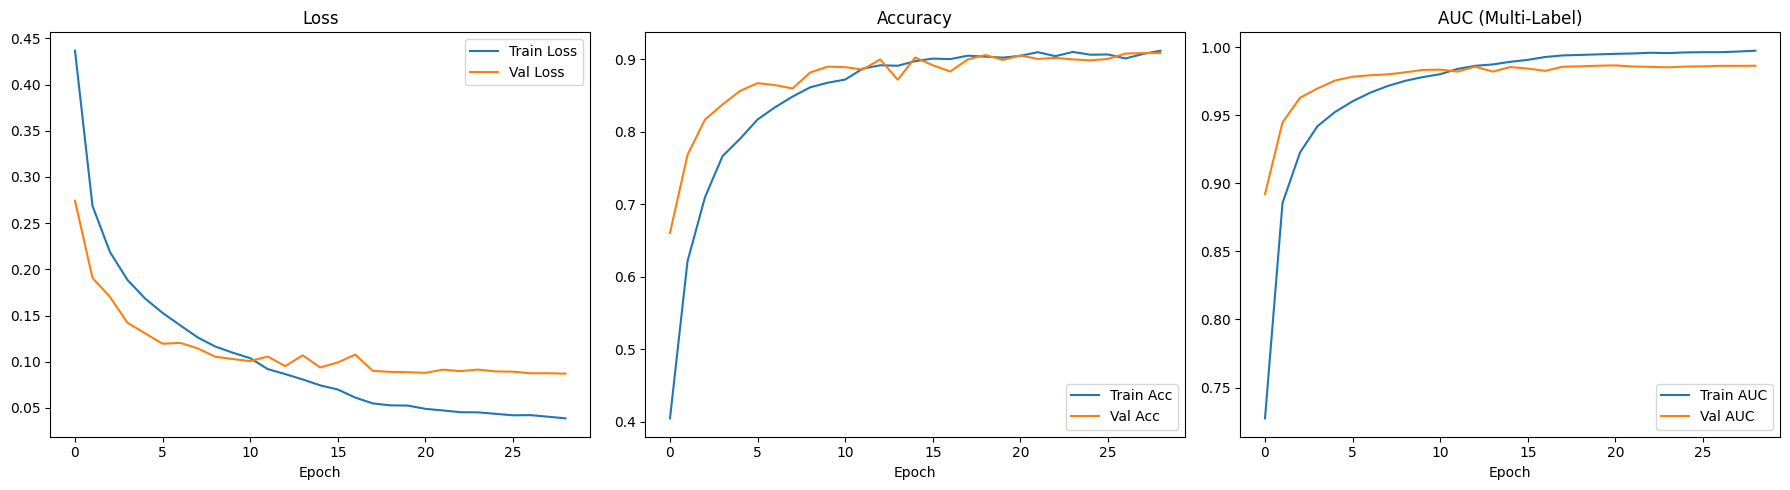

Saved: training_history/training_curves.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['auc'],     label='Train AUC')
axes[2].plot(history.history['val_auc'], label='Val AUC')
axes[2].set_title('AUC (Multi-Label)')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig('training_history/training_curves.png', dpi=120)
plt.show()
print("Saved: training_history/training_curves.png")

In [ ]:
### Evaluation

In [ ]:
from sklearn.model_selection import train_test_split

X_trainval, X_test, y_trainval, y_test = train_test_split(
    all_images, all_labels,
    test_size=0.10,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.20,
    random_state=42
)

print(f"Train set : {len(X_train)} images")
print(f"Val set   : {len(X_val)} images")
print(f"Test set  : {len(X_test)} images  ← held out, never seen during training")

Train set : 5382 images
Val set   : 1346 images
Test set  : 748 images  ← held out, never seen during training


In [ ]:
print("\n" + "="*90)
print(" EVALUATION ON VALIDATION SET ".center(90))
print("="*90)

# Get all predictions
all_preds_prob = model.predict(X_val, batch_size=BATCH_SIZE, verbose=1)
all_preds_bin  = (all_preds_prob > THRESHOLD).astype(int)

# Metrics
hl   = hamming_loss(y_val, all_preds_bin)
f1_micro = f1_score(y_val, all_preds_bin, average='micro', zero_division=0)
f1_macro = f1_score(y_val, all_preds_bin, average='macro', zero_division=0)

print(f"\nThreshold used     : {THRESHOLD}")
print(f"Hamming Loss        : {hl:.4f}  (lower is better, 0 = perfect)")
print(f"F1 Score (micro)    : {f1_micro:.4f}")
print(f"F1 Score (macro)    : {f1_macro:.4f}")

# Per-class report
print("\nPer-class Report:")
print(classification_report(y_val, all_preds_bin, target_names=CLASS_NAMES, zero_division=0))

# Check multi-disease detection performance
multi_label_mask   = y_val.sum(axis=1) > 1
multi_preds_bin    = all_preds_bin[multi_label_mask]
multi_preds_actual = y_val[multi_label_mask]

if multi_label_mask.sum() > 0:
    multi_f1 = f1_score(multi_preds_actual, multi_preds_bin, average='micro', zero_division=0)
    print(f"\nMulti-disease samples in val set: {multi_label_mask.sum()}")
    print(f"F1 on multi-disease samples only : {multi_f1:.4f}")
else:
    print("\nNo multi-disease samples in validation set (increase BLEND_RATIO to generate more)")


                               EVALUATION ON VALIDATION SET                               
43/43 ━━━━━━━━━━━━━━━━━━━━ 743s 17s/step

Threshold used     : 0.35
Hamming Loss        : 0.0123  (lower is better, 0 = perfect)
F1 Score (micro)    : 0.9605
F1 Score (macro)    : 0.9590

Per-class Report:
                        precision    recall  f1-score   support

       Bacteria Blight       0.97      0.99      0.98       147
            Brown spot       0.99      0.99      0.99       230
    Caterpillar Damage       0.95      0.98      0.96       152
                   Dry       1.00      1.00      1.00       118
               Healthy       0.97      0.99      0.98       304
     Kanamadiri haniya       0.85      0.96      0.91       171
             Leaf spot       0.94      0.98      0.96       360
Red Spider mite Damage       0.84      0.94      0.89       153

             micro avg       0.94      0.98      0.96      1635
             macro avg       0.94      0.98      0.96      1

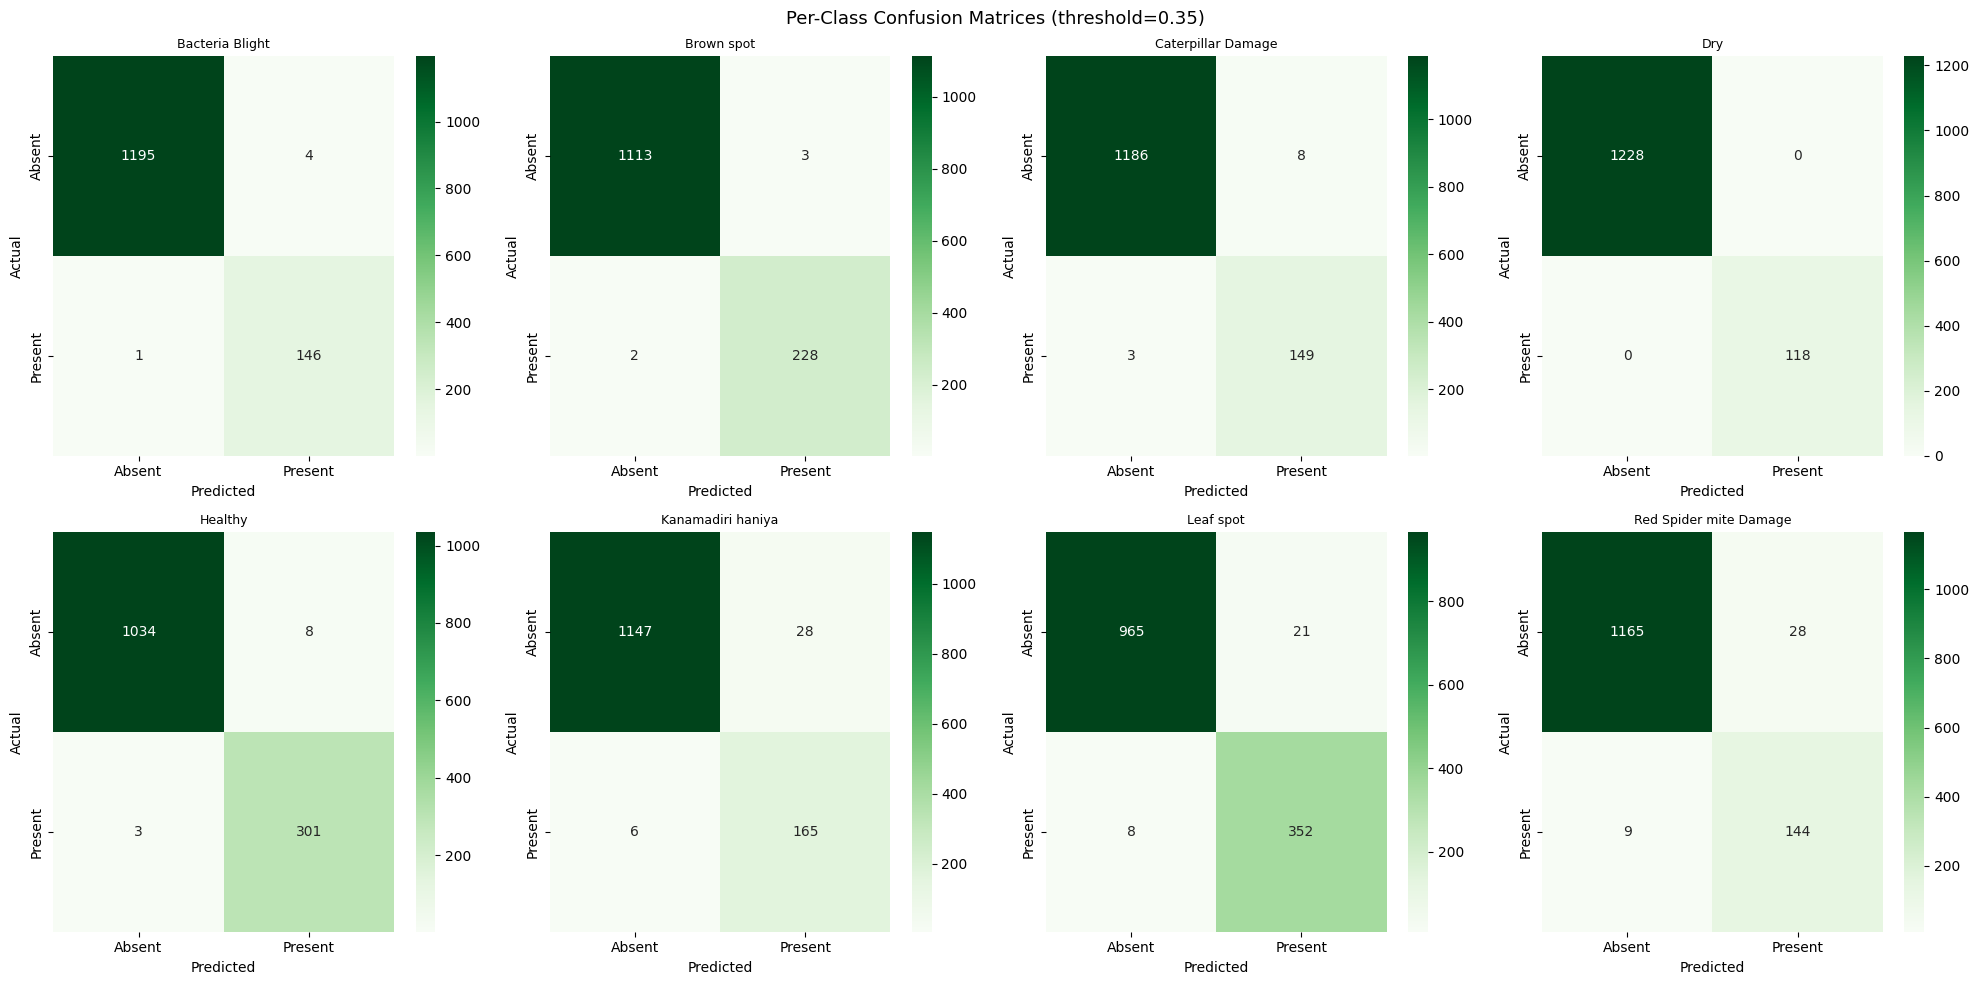

Saved: training_history/confusion_matrices.png


In [ ]:
# Confusion matrix (per-class binary)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    cm = confusion_matrix(y_val[:, i], all_preds_bin[:, i])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                xticklabels=['Absent','Present'],
                yticklabels=['Absent','Present'],
                cmap='Greens')
    axes[i].set_title(cls, fontsize=9)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle(f'Per-Class Confusion Matrices (threshold={THRESHOLD})', fontsize=13)
plt.tight_layout()
plt.savefig('training_history/confusion_matrices.png', dpi=120)
plt.show()
print("Saved: training_history/confusion_matrices.png")

In [ ]:
####Test Inference (Single & Multi-Disease)

In [ ]:
def predict_diseases(img_path, threshold=THRESHOLD):
    """
    Predict diseases in a single image.
    Returns all diseases detected above the threshold, sorted by confidence.
    This is exactly how your mobile app backend should call the model.
    """
    img   = load_and_preprocess(img_path)
    inp   = np.expand_dims(img, axis=0)
    preds = model.predict(inp, verbose=0)[0]

    results = []
    for i, conf in enumerate(preds):
        if conf >= threshold:
            results.append((CLASS_NAMES[i], float(conf)))

    results.sort(key=lambda x: x[1], reverse=True)
    return results

# Test on real single-disease images
print("\n" + "="*80)
print(" SINGLE-DISEASE INFERENCE TEST ".center(80))
print("="*80)
print(f"{'Actual':22} {'Predicted Diseases':45} {'Confidences':20}")
print("-"*90)

for cls in CLASS_NAMES[:4]:
    path = random.choice(class_images[cls])
    results = predict_diseases(path)
    pred_str = ", ".join([r[0] for r in results]) if results else "None detected"
    conf_str = ", ".join([f"{r[1]*100:.1f}%" for r in results]) if results else "-"
    hit = "OK" if any(r[0] == cls for r in results) else "MISS"
    print(f"[{hit}] {cls:20} {pred_str:45} {conf_str}")

# Test on synthetic 2-disease images
print("\n" + "="*80)
print(" MULTI-DISEASE INFERENCE TEST (synthetic blends) ".center(80))
print("="*80)
print(f"{'Actual Diseases':45} {'Predicted Diseases':45} {'Confidences':20}")
print("-"*110)

test_pairs = random.sample(disease_pairs, min(4, len(disease_pairs)))
for cls1, cls2 in test_pairs:
    p1 = random.choice(class_images[cls1])
    p2 = random.choice(class_images[cls2])

    blended_img = blend_images(p1, p2)
    inp         = np.expand_dims(blended_img, axis=0)
    preds       = model.predict(inp, verbose=0)[0]

    results  = [(CLASS_NAMES[i], float(preds[i])) for i in range(NUM_CLASSES) if preds[i] >= THRESHOLD]
    results.sort(key=lambda x: x[1], reverse=True)

    actual   = f"{cls1} + {cls2}"
    pred_str = ", ".join([r[0] for r in results]) if results else "None detected"
    conf_str = ", ".join([f"{r[1]*100:.1f}%" for r in results]) if results else "-"

    both_found = any(r[0]==cls1 for r in results) and any(r[0]==cls2 for r in results)
    hit = "BOTH" if both_found else ("ONE" if results else "NONE")
    print(f"[{hit}] {actual:43} {pred_str:45} {conf_str}")


                         SINGLE-DISEASE INFERENCE TEST                          
Actual                 Predicted Diseases                            Confidences         
------------------------------------------------------------------------------------------
[OK] Bacteria Blight      Bacteria Blight                               100.0%
[OK] Brown spot           Brown spot                                    100.0%
[OK] Caterpillar Damage   Caterpillar Damage                            100.0%
[OK] Dry                  Dry                                           100.0%

                MULTI-DISEASE INFERENCE TEST (synthetic blends)                 
Actual Diseases                               Predicted Diseases                            Confidences         
--------------------------------------------------------------------------------------------------------------
[ONE] Caterpillar Damage + Dry                    Caterpillar Damage, Bacteria Blight           99.9%, 55.5%
[BOTH]

In [ ]:
#### Final Summary

In [ ]:
# ── Metrics from training history ────────────────────────────────────────────
train_acc  = max(history.history['accuracy']) * 100
val_acc    = max(history.history['val_accuracy']) * 100
train_auc  = max(history.history['auc'])
val_auc    = max(history.history['val_auc'])
gap        = train_acc - val_acc

# ── Test set evaluation (true held-out data) ──────────────────────────────────
print("Evaluating on held-out test set...")
test_gen = MultiLabelGenerator(X_test, y_test, batch_size=BATCH_SIZE, augment=False)
test_loss, test_acc_raw, test_auc = model.evaluate(test_gen, verbose=1)
test_acc = test_acc_raw * 100

# Per-label test predictions
test_preds_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_preds_bin  = (test_preds_prob > THRESHOLD).astype(int)

test_hl      = hamming_loss(y_test, test_preds_bin)
test_f1_micro = f1_score(y_test, test_preds_bin, average='micro', zero_division=0)
test_f1_macro = f1_score(y_test, test_preds_bin, average='macro', zero_division=0)

print(f"\nTest Accuracy  : {test_acc:.2f}%")
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test AUC       : {test_auc:.4f}")
print(f"Test Hamming   : {test_hl:.4f}")
print(f"Test F1 Micro  : {test_f1_micro:.4f}")

# ── Diagnosis ─────────────────────────────────────────────────────────────────
def diagnose(train_acc, val_acc, test_acc, val_auc):
    gap_train_val  = train_acc - val_acc
    gap_val_test   = val_acc - test_acc
    if train_acc < 75:
        return "Underfitting — increase epochs or unfreeze more layers"
    if gap_train_val > 12:
        return "Overfitting — add more data or stronger regularization"
    if gap_val_test > 10:
        return "Validation/Test gap — check for data leakage"
    if gap_train_val > 5:
        return "Mild overfitting — acceptable"
    if val_auc >= 0.90 and test_auc >= 0.88:
        return "Excellent — ready for deployment"
    return "Good fit"

# ── Summary table ─────────────────────────────────────────────────────────────
df = pd.DataFrame({
    "Model"           : ["Hybrid VGG16+DenseNet121 (Multi-Label)"],
    "Train Acc (%)"   : [f"{train_acc:.2f}"],
    "Val Acc (%)"     : [f"{val_acc:.2f}"],
    "Test Acc (%)"    : [f"{test_acc:.2f}"],
    "Test Loss"       : [f"{test_loss:.4f}"],
    "Val AUC"         : [f"{val_auc:.4f}"],
    "Test AUC"        : [f"{test_auc:.4f}"],
    "Hamming Loss"    : [f"{test_hl:.4f}"],
    "F1 Micro"        : [f"{test_f1_micro:.4f}"],
    "F1 Macro"        : [f"{test_f1_macro:.4f}"],
    "Train/Val Gap"   : [f"{gap:+.2f}%"],
    "Diagnosis"       : [diagnose(train_acc, val_acc, test_acc, val_auc)]
})

print("\n" + "="*110)
print(" FINAL SUMMARY ".center(110))
print("="*110)
print(df.to_string(index=False))
print("="*110)

print("\nSaved files:")
print("  saved_model/Multi_Disease_N.tflite")
print("  saved_model/best_multi_disease_N.keras")
print("  training_history/training_curves.png")
print("  training_history/confusion_matrices.png")
print("  training_history/synthetic_samples.png")
for i, name in enumerate(CLASS_NAMES):
    print(f"  [{i}] {name}")
print(f"\n*** THRESHOLD = {THRESHOLD} — ***")


Evaluating on held-out test set...


C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


24/24 ━━━━━━━━━━━━━━━━━━━━ 410s 17s/step - accuracy: 0.9104 - auc: 0.9879 - loss: 0.0798
24/24 ━━━━━━━━━━━━━━━━━━━━ 412s 17s/step

Test Accuracy  : 91.04%
Test Loss      : 0.0798
Test AUC       : 0.9879
Test Hamming   : 0.0344
Test F1 Micro  : 0.8911

                                                FINAL SUMMARY                                                 
                                 Model Train Acc (%) Val Acc (%) Test Acc (%) Test Loss Val AUC Test AUC Hamming Loss F1 Micro F1 Macro Train/Val Gap                        Diagnosis
Hybrid VGG16+DenseNet121 (Multi-Label)         91.17       90.84        91.04    0.0798  0.9867   0.9879       0.0344   0.8911   0.8811        +0.33% Excellent — ready for deployment

Saved files:
  saved_model/Multi_Disease_N.tflite
  saved_model/best_multi_disease_N.keras
  training_history/training_curves.png
  training_history/confusion_matrices.png
  training_history/synthetic_samples.png
  [0] Bacteria Blight
  [1] Brown spot
  [2] Caterpillar 

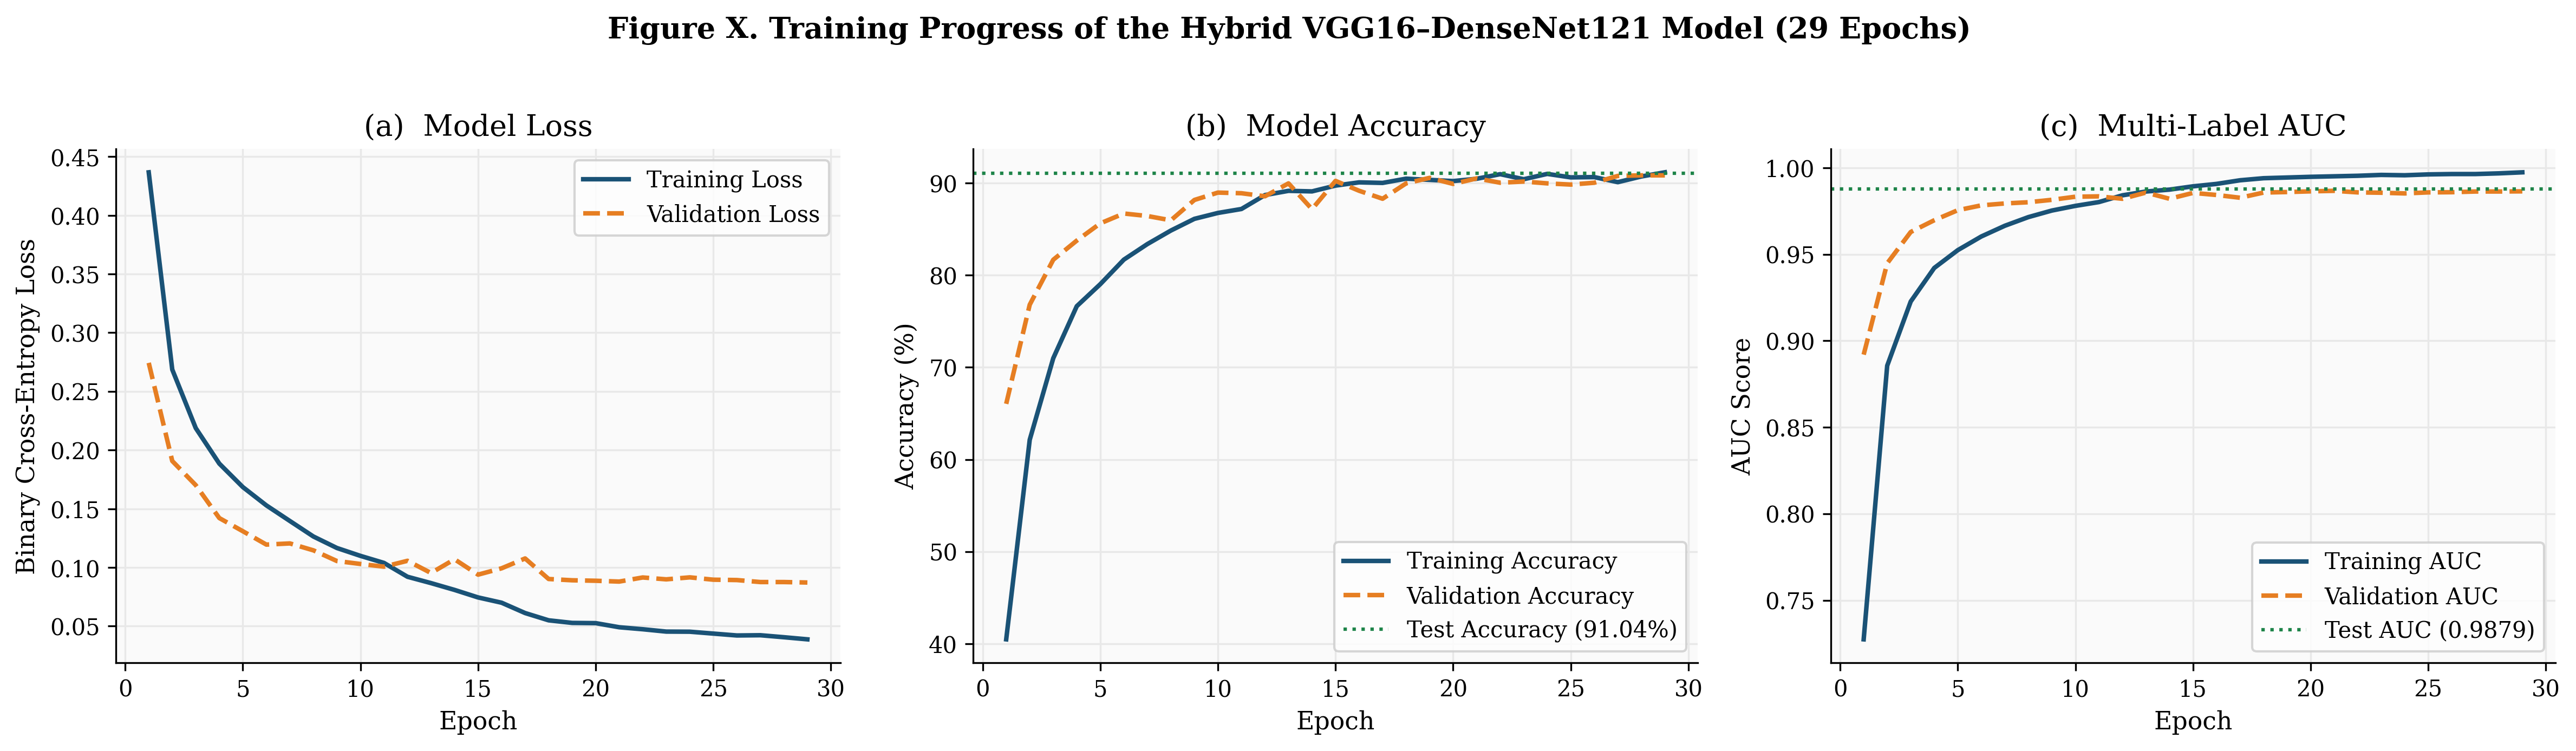

Saved: fig1_training_curves.png


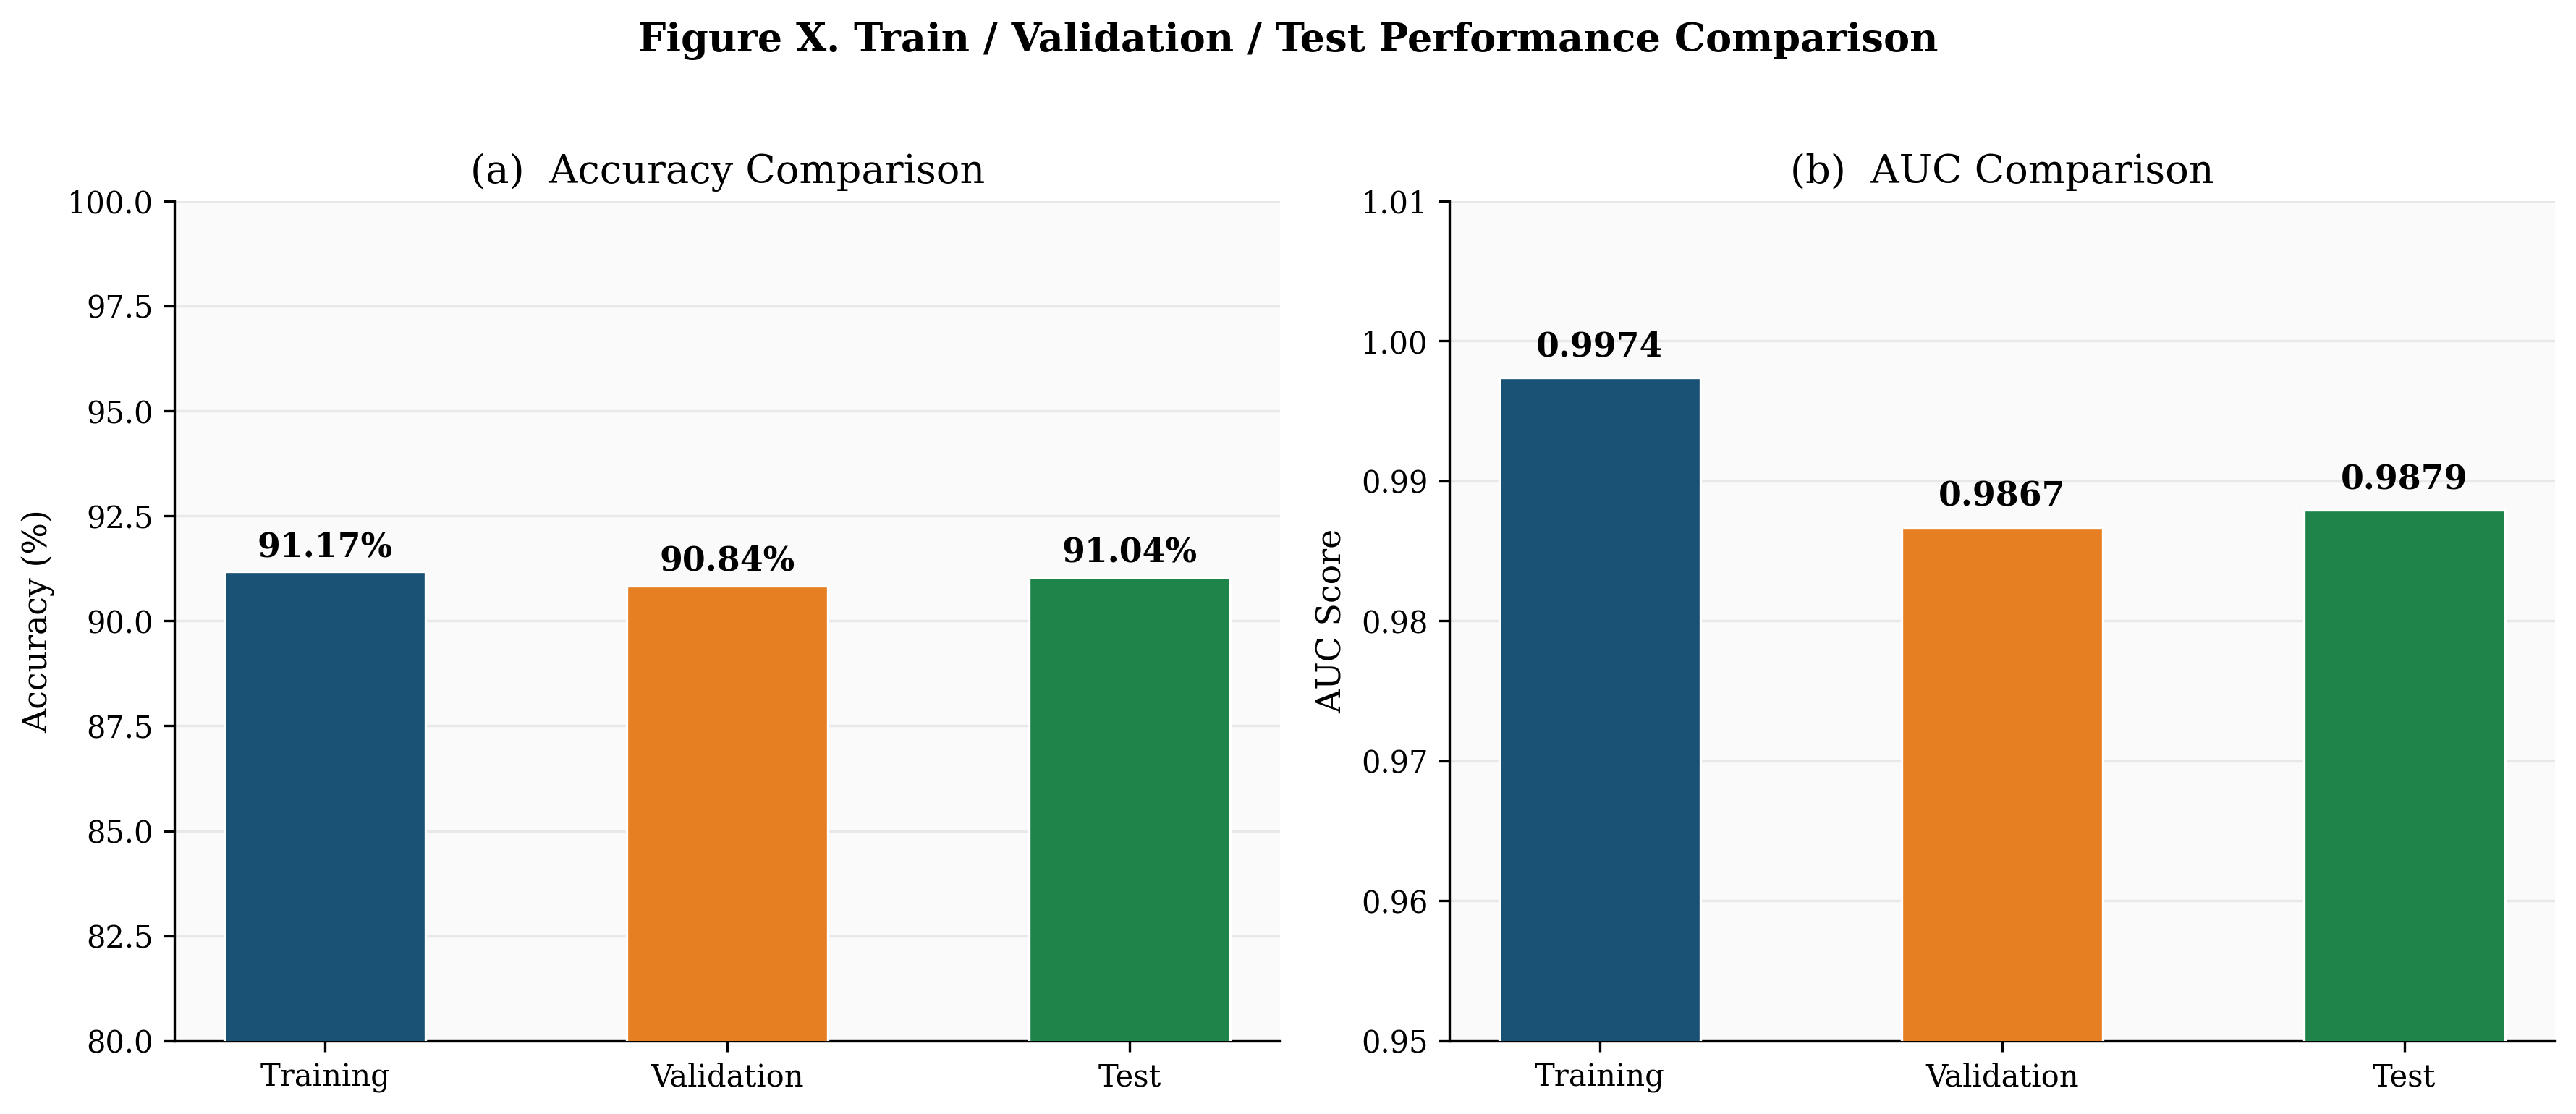

Saved: fig2_train_val_test_comparison.png


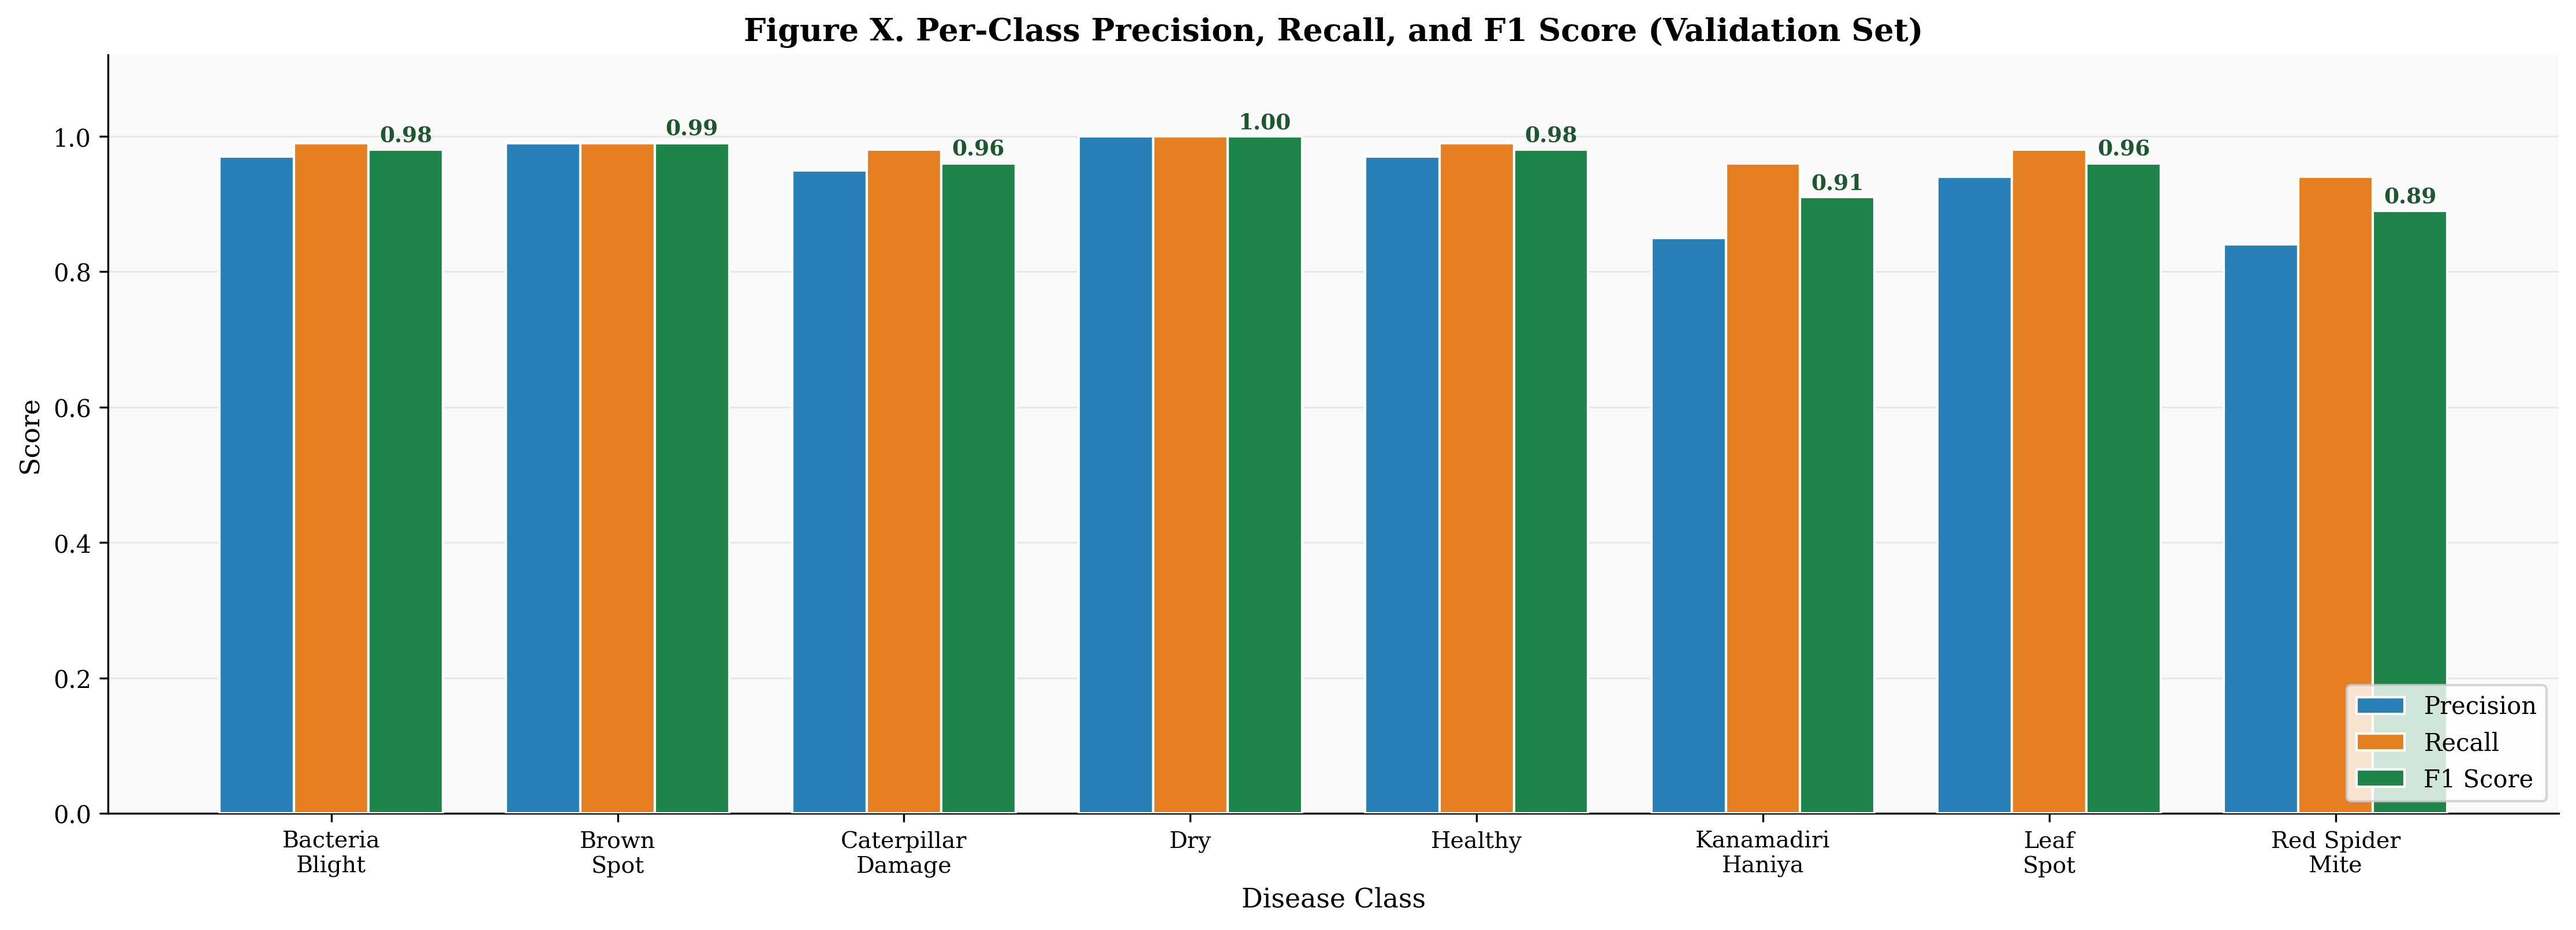

Saved: fig3_per_class_metrics.png


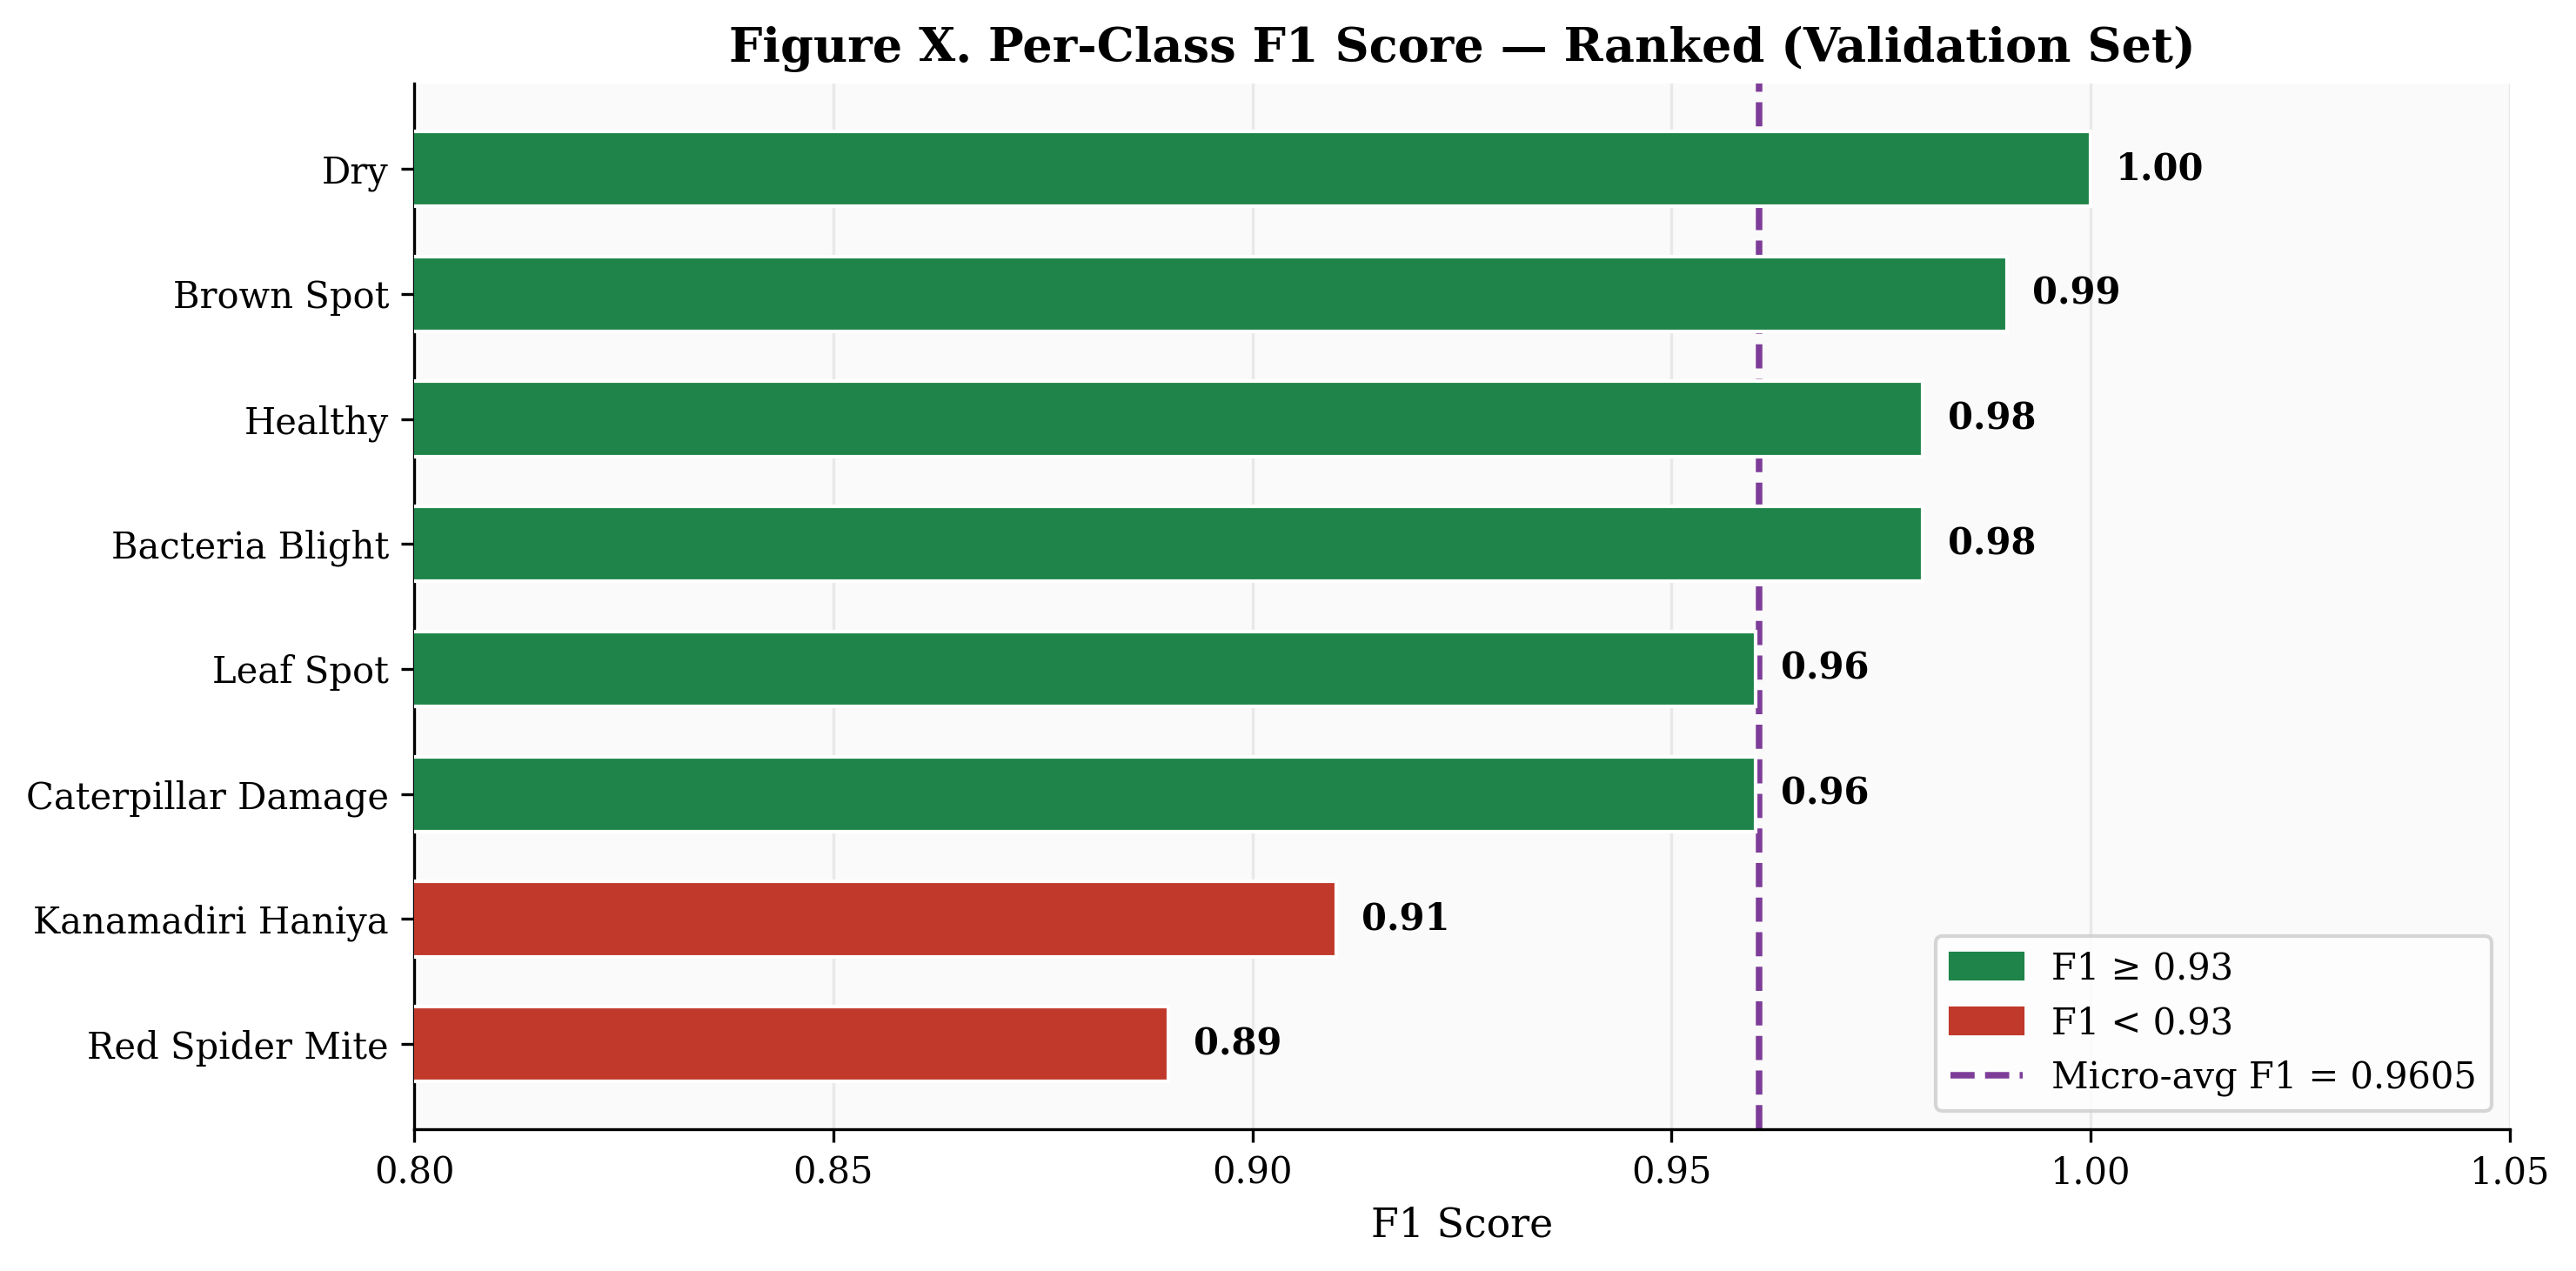

Saved: fig4_f1_ranked.png


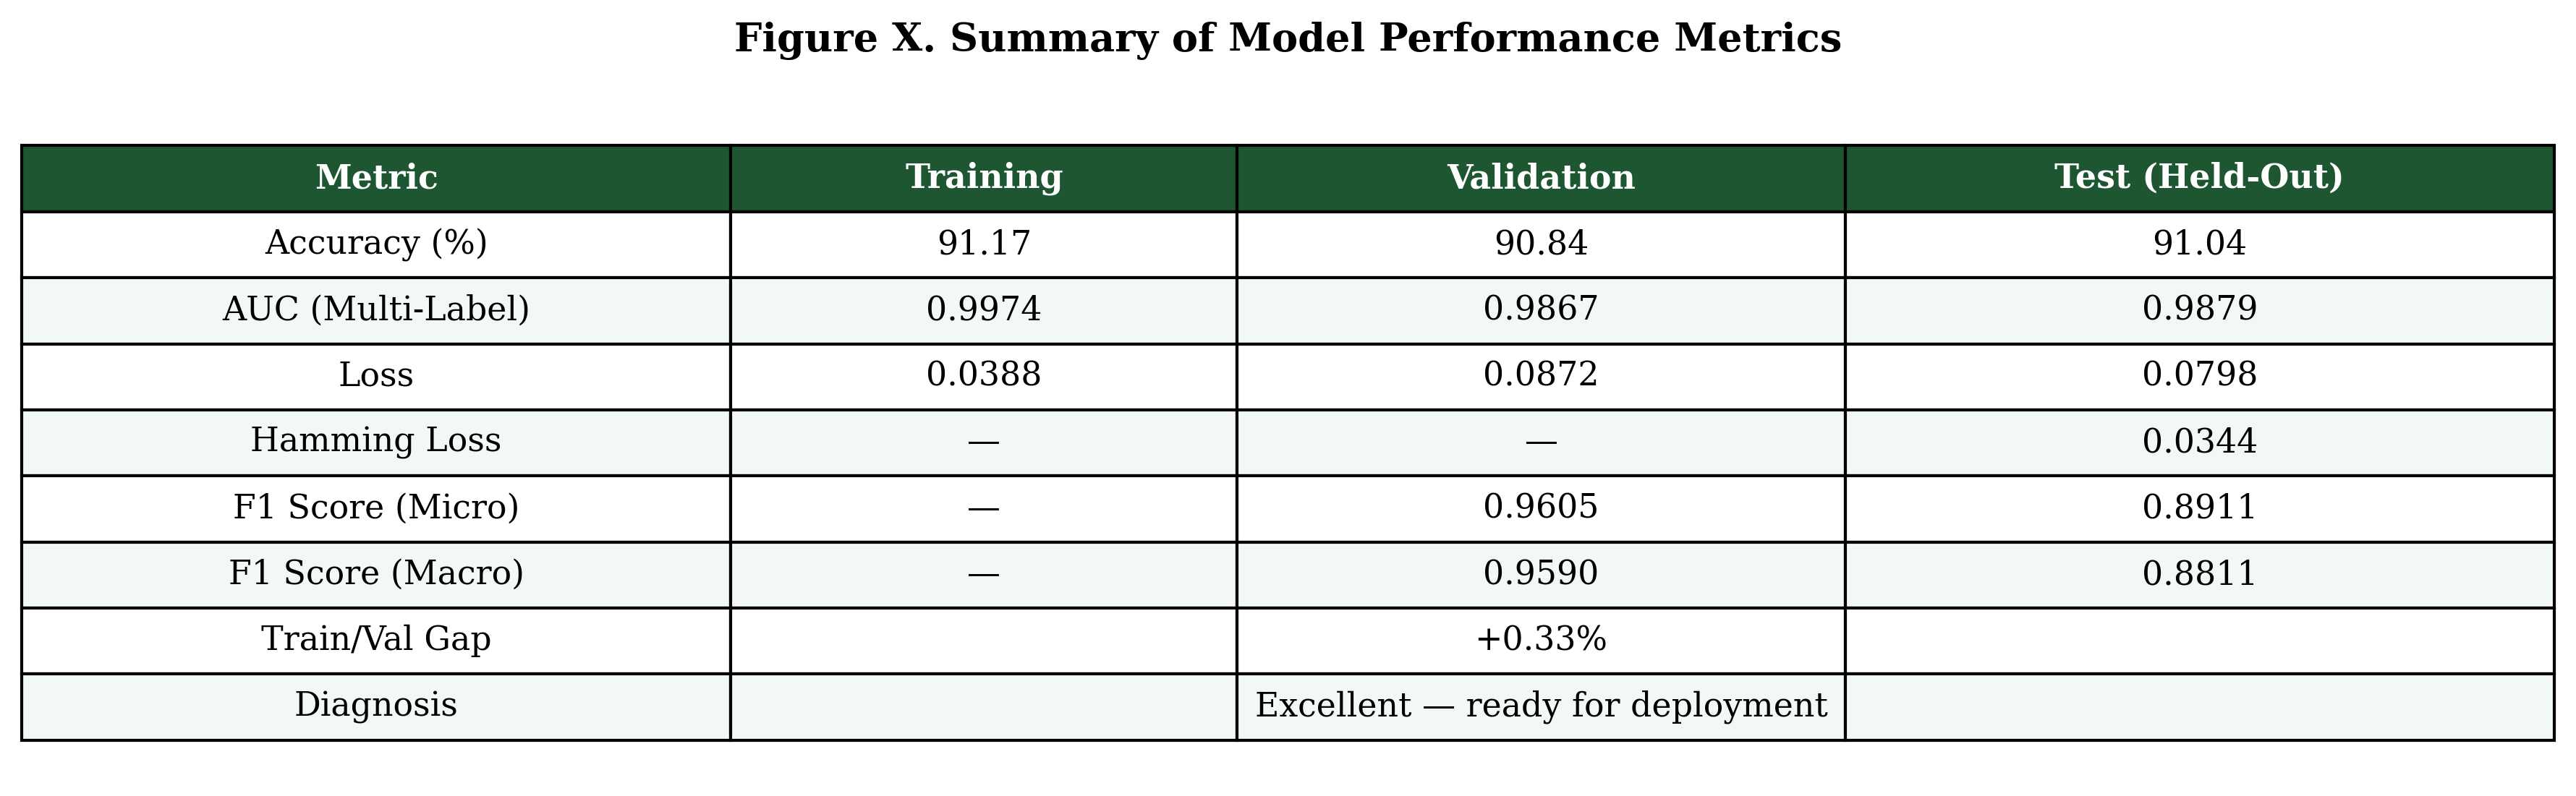

Saved: fig5_metrics_table.png

             ALL 5 FIGURES SAVED TO training_history/            
  fig1_training_curves.png          — Learning progress (29 epochs)
  fig2_train_val_test_comparison.png — Generalisation bar chart
  fig3_per_class_metrics.png         — Precision / Recall / F1
  fig4_f1_ranked.png                 — F1 scores ranked
  fig5_metrics_table.png             — Summary metrics table


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

os.makedirs('training_history', exist_ok=True)

# ── Publication style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'    : 'serif',
    'font.size'      : 11,
    'axes.titlesize' : 13,
    'axes.labelsize' : 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'savefig.dpi'    : 300,
    'savefig.bbox'   : 'tight',
})

COLORS = {
    'train' : '#1a5276',
    'val'   : '#e67e22',
    'test'  : '#1e8449',
    'grid'  : '#e8e8e8',
}

# ── Real training history (29 epochs, extracted from notebook outputs) ────────
history = {
    'accuracy'     : [0.4048,0.6214,0.7099,0.7664,0.7903,0.8169,0.8338,0.8485,0.8612,0.8676,
                      0.8719,0.8870,0.8916,0.8910,0.8973,0.9008,0.9002,0.9048,0.9035,0.9022,
                      0.9047,0.9097,0.9042,0.9100,0.9062,0.9065,0.9010,0.9072,0.9117],
    'val_accuracy' : [0.6604,0.7680,0.8168,0.8376,0.8563,0.8670,0.8643,0.8596,0.8817,0.8897,
                      0.8890,0.8857,0.8997,0.8717,0.9024,0.8917,0.8830,0.8997,0.9057,0.8991,
                      0.9051,0.9004,0.9017,0.8997,0.8984,0.9004,0.9078,0.9084,0.9084],
    'loss'         : [0.4366,0.2686,0.2187,0.1885,0.1685,0.1529,0.1396,0.1264,0.1166,0.1099,
                      0.1039,0.0921,0.0867,0.0809,0.0745,0.0700,0.0612,0.0550,0.0528,0.0526,
                      0.0491,0.0474,0.0454,0.0453,0.0437,0.0421,0.0423,0.0406,0.0388],
    'val_loss'     : [0.2743,0.1907,0.1701,0.1421,0.1309,0.1195,0.1205,0.1146,0.1055,0.1030,
                      0.1007,0.1057,0.0953,0.1070,0.0939,0.0993,0.1077,0.0902,0.0891,0.0887,
                      0.0880,0.0915,0.0899,0.0916,0.0896,0.0893,0.0876,0.0876,0.0872],
    'auc'          : [0.7274,0.8856,0.9227,0.9421,0.9524,0.9603,0.9665,0.9715,0.9753,0.9780,
                      0.9802,0.9841,0.9863,0.9874,0.9893,0.9907,0.9928,0.9940,0.9944,0.9948,
                      0.9951,0.9954,0.9959,0.9957,0.9962,0.9964,0.9964,0.9968,0.9974],
    'val_auc'      : [0.8920,0.9448,0.9629,0.9697,0.9755,0.9783,0.9794,0.9801,0.9815,0.9833,
                      0.9835,0.9821,0.9857,0.9821,0.9855,0.9843,0.9827,0.9857,0.9860,0.9864,
                      0.9867,0.9858,0.9856,0.9852,0.9858,0.9859,0.9863,0.9863,0.9864],
}

# ── Final summary metrics (from notebook Final Summary output) ─────────────────
train_acc     = 91.17
val_acc       = 90.84
test_acc      = 91.04
test_loss     = 0.0798
val_auc       = 0.9867
test_auc      = 0.9879
train_auc     = max(history['auc'])
test_hl       = 0.0344
test_f1_micro = 0.8911
test_f1_macro = 0.8811
f1_micro      = 0.9605   # from validation classification report
f1_macro      = 0.9590

# ── Per-class metrics from validation classification report ────────────────────
CLASS_NAMES = [
    'Bacteria Blight', 'Brown spot', 'Caterpillar Damage', 'Dry',
    'Healthy', 'Kanamadiri haniya', 'Leaf spot', 'Red Spider mite Damage'
]
SHORT_NAMES = [
    'Bacteria\nBlight', 'Brown\nSpot', 'Caterpillar\nDamage', 'Dry',
    'Healthy', 'Kanamadiri\nHaniya', 'Leaf\nSpot', 'Red Spider\nMite'
]

precision_per_class = [0.97, 0.99, 0.95, 1.00, 0.97, 0.85, 0.94, 0.84]
recall_per_class    = [0.99, 0.99, 0.98, 1.00, 0.99, 0.96, 0.98, 0.94]
f1_per_class        = [0.98, 0.99, 0.96, 1.00, 0.98, 0.91, 0.96, 0.89]
support_per_class   = [147,  230,  152,  118,  304,  171,  360,  153 ]

epochs = range(1, len(history['loss']) + 1)


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Training Curves (Loss / Accuracy / AUC)
# ═════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax in axes:
    ax.set_facecolor('#fafafa')
    ax.grid(True, color=COLORS['grid'], linewidth=0.8, zorder=0)
    ax.spines[['top','right']].set_visible(False)

# Loss
axes[0].plot(epochs, history['loss'],     color=COLORS['train'], linewidth=2,   label='Training Loss')
axes[0].plot(epochs, history['val_loss'], color=COLORS['val'],   linewidth=2,   label='Validation Loss', linestyle='--')
axes[0].set_title('(a)  Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()

# Accuracy
axes[1].plot(epochs, [v*100 for v in history['accuracy']],     color=COLORS['train'], linewidth=2, label='Training Accuracy')
axes[1].plot(epochs, [v*100 for v in history['val_accuracy']], color=COLORS['val'],   linewidth=2, label='Validation Accuracy', linestyle='--')
axes[1].axhline(y=test_acc, color=COLORS['test'], linewidth=1.5, linestyle=':', label=f'Test Accuracy ({test_acc:.2f}%)')
axes[1].set_title('(b)  Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()

# AUC
axes[2].plot(epochs, history['auc'],     color=COLORS['train'], linewidth=2, label='Training AUC')
axes[2].plot(epochs, history['val_auc'], color=COLORS['val'],   linewidth=2, label='Validation AUC', linestyle='--')
axes[2].axhline(y=test_auc, color=COLORS['test'], linewidth=1.5, linestyle=':', label=f'Test AUC ({test_auc:.4f})')
axes[2].set_title('(c)  Multi-Label AUC')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC Score')
axes[2].legend()

plt.suptitle('Figure X. Training Progress of the Hybrid VGG16–DenseNet121 Model (29 Epochs)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_history/fig1_training_curves.png')
plt.show()
print("Saved: fig1_training_curves.png")


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Train / Validation / Test Comparison Bar Chart
# ═════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax in axes:
    ax.set_facecolor('#fafafa')
    ax.grid(True, axis='y', color=COLORS['grid'], linewidth=0.8, zorder=0)
    ax.spines[['top','right']].set_visible(False)

x      = np.arange(3)
labels = ['Training', 'Validation', 'Test']
width  = 0.5
bar_colors = [COLORS['train'], COLORS['val'], COLORS['test']]

# Accuracy
acc_vals = [train_acc, val_acc, test_acc]
bars = axes[0].bar(x, acc_vals, width, color=bar_colors, edgecolor='white', linewidth=0.8, zorder=3)
axes[0].set_title('(a)  Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(80, 100)
for bar, val in zip(bars, acc_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# AUC
auc_vals = [train_auc, val_auc, test_auc]
bars2 = axes[1].bar(x, auc_vals, width, color=bar_colors, edgecolor='white', linewidth=0.8, zorder=3)
axes[1].set_title('(b)  AUC Comparison')
axes[1].set_ylabel('AUC Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylim(0.95, 1.01)
for bar, val in zip(bars2, auc_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Figure X. Train / Validation / Test Performance Comparison',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_history/fig2_train_val_test_comparison.png')
plt.show()
print("Saved: fig2_train_val_test_comparison.png")


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Per-Class Precision, Recall and F1 Score
# ═════════════════════════════════════════════════════════════════════════════
x     = np.arange(len(CLASS_NAMES))
width = 0.26

fig, ax = plt.subplots(figsize=(15, 5.5))
ax.set_facecolor('#fafafa')
ax.grid(True, axis='y', color=COLORS['grid'], linewidth=0.8, zorder=0)
ax.spines[['top','right']].set_visible(False)

b1 = ax.bar(x - width, precision_per_class, width, label='Precision', color='#2980b9', edgecolor='white', zorder=3)
b2 = ax.bar(x,         recall_per_class,    width, label='Recall',    color='#e67e22', edgecolor='white', zorder=3)
b3 = ax.bar(x + width, f1_per_class,        width, label='F1 Score',  color='#1e8449', edgecolor='white', zorder=3)

for bar, val in zip(b3, f1_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1e5631')

ax.set_title('Figure X. Per-Class Precision, Recall, and F1 Score (Validation Set)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Disease Class')
ax.set_xticks(x)
ax.set_xticklabels(SHORT_NAMES, fontsize=9.5)
ax.set_ylim(0, 1.12)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('training_history/fig3_per_class_metrics.png')
plt.show()
print("Saved: fig3_per_class_metrics.png")


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Per-Class F1 Score Ranked Bar Chart
# Clean single-metric chart suitable for the paper results section.
# ═════════════════════════════════════════════════════════════════════════════
sorted_idx  = np.argsort(f1_per_class)
sorted_f1   = [f1_per_class[i] for i in sorted_idx]
sorted_names= [SHORT_NAMES[i].replace('\n', ' ') for i in sorted_idx]
bar_clrs    = ['#c0392b' if v < 0.93 else '#1e8449' for v in sorted_f1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor('#fafafa')
ax.grid(True, axis='x', color=COLORS['grid'], linewidth=0.8, zorder=0)
ax.spines[['top','right']].set_visible(False)

bars = ax.barh(sorted_names, sorted_f1, color=bar_clrs, edgecolor='white', height=0.6, zorder=3)
ax.axvline(x=f1_micro, color='#7d3c98', linewidth=1.8, linestyle='--',
           label=f'Micro-avg F1 = {f1_micro:.4f}')
ax.set_xlim(0.80, 1.05)
ax.set_xlabel('F1 Score')
ax.set_title('Figure X. Per-Class F1 Score — Ranked (Validation Set)', fontsize=13, fontweight='bold')

for bar, val in zip(bars, sorted_f1):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

green_patch = mpatches.Patch(color='#1e8449', label='F1 ≥ 0.93')
red_patch   = mpatches.Patch(color='#c0392b', label='F1 < 0.93')
ax.legend(handles=[green_patch, red_patch,
                   plt.Line2D([0],[0], color='#7d3c98', linewidth=1.8, linestyle='--',
                              label=f'Micro-avg F1 = {f1_micro:.4f}')],
          loc='lower right')

plt.tight_layout()
plt.savefig('training_history/fig4_f1_ranked.png')
plt.show()
print("Saved: fig4_f1_ranked.png")


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 5 — Summary Metrics Visual Table
# ═════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.axis('off')

table_data = [
    ['Metric',             'Training',         'Validation',       'Test (Held-Out)'],
    ['Accuracy (%)',       f'{train_acc:.2f}',  f'{val_acc:.2f}',   f'{test_acc:.2f}'],
    ['AUC (Multi-Label)',  f'{train_auc:.4f}',  f'{val_auc:.4f}',   f'{test_auc:.4f}'],
    ['Loss',               f'{min(history["loss"]):.4f}',
                           f'{min(history["val_loss"]):.4f}',
                           f'{test_loss:.4f}'],
    ['Hamming Loss',       '—',                 '—',                f'{test_hl:.4f}'],
    ['F1 Score (Micro)',   '—',                 f'{f1_micro:.4f}',  f'{test_f1_micro:.4f}'],
    ['F1 Score (Macro)',   '—',                 f'{f1_macro:.4f}',  f'{test_f1_macro:.4f}'],
    ['Train/Val Gap',      '',                  f'+{train_acc-val_acc:.2f}%', ''],
    ['Diagnosis',          '',                  'Excellent — ready for deployment', ''],
]

tbl = ax.table(
    cellText  = table_data[1:],
    colLabels = table_data[0],
    cellLoc   = 'center',
    loc       = 'center',
    colWidths = [0.28, 0.20, 0.24, 0.28],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.75)

for col in range(4):
    tbl[0, col].set_facecolor('#1e5631')
    tbl[0, col].set_text_props(color='white', fontweight='bold')

for row in range(1, len(table_data)):
    shade = '#f2f8f4' if row % 2 == 0 else 'white'
    for col in range(4):
        tbl[row, col].set_facecolor(shade)

ax.set_title('Figure X. Summary of Model Performance Metrics',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('training_history/fig5_metrics_table.png')
plt.show()
print("Saved: fig5_metrics_table.png")


print("\n" + "="*65)
print(" ALL 5 FIGURES SAVED TO training_history/ ".center(65))
print("="*65)
print("  fig1_training_curves.png          — Learning progress (29 epochs)")
print("  fig2_train_val_test_comparison.png — Generalisation bar chart")
print("  fig3_per_class_metrics.png         — Precision / Recall / F1")
print("  fig4_f1_ranked.png                 — F1 scores ranked")
print("  fig5_metrics_table.png             — Summary metrics table")
print("="*65)